# TRIBE v2 Demo: Predicting Brain Responses to Naturalistic Stimuli

[TRIBE v2](https://github.com/facebookresearch/tribev2) is a deep multimodal brain encoding model that predicts **fMRI brain responses** to naturalistic stimuli — video, audio, and text.

It combines state-of-the-art feature extractors — **LLaMA 3.2** (text), **V-JEPA2** (video), and **Wav2Vec-BERT** (audio) — into a unified Transformer that maps multimodal representations onto the cortical surface (**fsaverage5**, ~20k vertices).

In this notebook, we will:
1. Load a pretrained TRIBE v2 model from HuggingFace
2. Predict brain responses to a **video** clip
3. Predict brain responses to **audio** generated from text
4. Visualize the predicted activity on a 3D brain surface

## Setup (for Colab users)

1. Activate the GPU (Menu > Runtime > Change runtime)
2. Run the command below
3. Restart your environment for the new packages to be taken into account

In [1]:
!uv pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"

Using Python 3.12.13 environment at: /usr
Resolved 140 packages in 2.01s
Prepared 44 packages in 45.76s
Uninstalled 22 packages in 935ms
Installed 44 packages in 623ms
 - click==8.3.1
 + click==8.1.8
 + cyclopts==4.10.1
 + exca==0.5.22
 + gtts==2.5.4
 + julius==0.2.7
 + langdetect==1.0.9
 + levenshtein==0.27.3
 + lightning-utilities==0.15.3
 + mne==1.11.0
 + mne-bids==0.18.0
 - moviepy==1.0.3
 + moviepy==2.2.1
 + neuralset==0.0.2
 + neuraltrain==0.0.2
 + nilearn==0.13.1
 - numpy==2.0.2
 + numpy==2.2.6
 - nvidia-cublas-cu12==12.8.4.1
 + nvidia-cublas-cu12==12.4.5.8
 - nvidia-cuda-cupti-cu12==12.8.90
 + nvidia-cuda-cupti-cu12==12.4.127
 - nvidia-cuda-nvrtc-cu12==12.8.93
 + nvidia-cuda-nvrtc-cu12==12.4.127
 - nvidia-cuda-runtime-cu12==12.8.90
 + nvidia-cuda-runtime-cu12==12.4.127
 - nvidia-cudnn-cu12==9.10.2.21
 + nvidia-cudnn-cu12==9.1.0.70
 - nvidia-cufft-cu12==11.3.3.83
 + nvidia-cufft-cu12==11.2.1.3
 - nvidia-curand-cu12==10.3.9.90
 + nvidia-curand-cu12==10.3.5.147
 - nvidia-cusolver-

## Loading the model

We load the pretrained TRIBE v2 model from the [HuggingFace Hub](https://huggingface.co/facebook/tribev2). On the first run, this downloads the model checkpoint and config (~1 GB). Subsequent runs use the cached version.

We also initialize a `PlotBrain` object for 3D brain surface visualization using the **fsaverage5** mesh.

In [2]:
from tribev2.demo_utils import TribeModel, download_file
from tribev2.plotting import PlotBrain
from pathlib import Path

CACHE_FOLDER = Path("./cache")

model = TribeModel.from_pretrained(
    "facebook/tribev2",
    cache_folder=CACHE_FOLDER,
)
plotter = PlotBrain(mesh="fsaverage5")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.yaml: 0.00B [00:00, ?B/s]

best.ckpt:   0%|          | 0.00/709M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-03-29 19:05:24 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
INFO:tribev2.demo_utils:Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
/usr/local/lib/python3.12/dist-packages/x_transformers/x_transformers.py:439: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('

## Predict brain responses to a video

Given a video file, TRIBE v2 automatically:
1. **Extracts audio** from the video track
2. **Transcribes speech** into word-level events with timestamps using [**WhisperX**](https://github.com/m-bain/whisperx)
3. **Extracts visual features** (DINOv2 + V-JEPA2) and **audio features** (Wav2Vec-BERT) and **text features** (LLaMA 3.2)
4. **Predicts fMRI activity** at each time step (1 TR = 1 second) across the cortical surface

Below, we download a sample video ([Sintel trailer](https://durian.blender.org/)), build an events dataframe, and run the model.

In [3]:
video_path = CACHE_FOLDER / "sample_video.mp4"
url = "https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4"
download_file(url, video_path)
df = model.get_events_dataframe(video_path=video_path)
display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

INFO - Downloaded https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4 -> cache/sample_video.mp4
INFO:tribev2.demo_utils:Downloaded https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4 -> cache/sample_video.mp4
Extract audio from video events:   0%|          | 0/1 [00:00<?, ?it/s]

MoviePy - Writing audio in cache/sample_video.wav



Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00,  1.28it/s]
/usr/local/lib/python3.12/dist-packages/neuralset/events/transforms/audio.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  events = pd.concat([events, pd.DataFrame(events_to_add)], ignore_index=True)
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)


MoviePy - Done.


Extracting words from audio: 100%|██████████| 1/1 [02:31<00:00, 151.89s/it]
/usr/local/lib/python3.12/dist-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Add context to words: 100%|██████████| 30/30 [00:00<00:00, 72398.80it/s]


,type,start,duration,filepath,text,context
0,Audio,0.000000,52.210000,cache/sample_video.wav,NaN,
1,Video,0.000000,52.210000,cache/sample_video.mp4,NaN,
2,Sentence,12.212999,2.042002,NaN,What brings you to the land of the gatekeepers?.,
3,Text,12.213000,31.490000,NaN,What brings you to the land of the gatekeepers...,
4,Word,12.213000,0.120000,NaN,What,What
5,Word,12.393000,0.280000,NaN,brings,What brings
6,Word,12.713000,0.101000,NaN,you,What brings you
7,Word,12.854000,0.100000,NaN,to,What brings you to


### Run the model

We feed the events dataframe to `model.predict()`, which extracts features for each modality, runs them through the Transformer, and returns predicted brain activity.

NOTE: you will have to request access to the Llama-3.2 model using your HuggingFace account.

The output `preds` has shape `(n_timesteps, n_vertices)` — one prediction per second of stimulus, with ~20k cortical vertices. The `segments` list contains the corresponding time segments with their associated events.

In [4]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")


[19:12:49 INFO] Preparing extractor: text
INFO:tribev2.main:Preparing extractor: text
Computing word embeddings:   0%|          | 0/8 [00:00<?, ?it/s]


OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/meta-llama/Llama-3.2-3B.
401 Client Error. (Request ID: Root=1-69c979b2-2b3ef9695657295f00590c01;39a5e536-2a1b-4cd5-bc55-ca34a117d369)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.2-3B/resolve/main/config.json.
Access to model meta-llama/Llama-3.2-3B is restricted. You must have access to it and be authenticated to access it. Please log in.

### Visualize predictions on the brain surface

We plot the predicted fMRI activity for the first 15 time steps on the fsaverage5 cortical mesh. Each panel shows one second of predicted activity, with the corresponding stimulus frame displayed below.

The `fire` colormap highlights regions of high predicted activation. The `norm_percentile=99` parameter normalizes values within the 99th percentile to avoid outlier-driven scaling.

In [ ]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.5, alpha_cmap=(0, .2), show_stimuli=True)

## Predict brain responses to text (via text-to-speech)

TRIBE v2 can also predict brain responses to **text** input. Since the model was trained on naturalistic audio/video stimuli, text is first converted to speech using Google Text-to-Speech (gTTS), then transcribed back to obtain precise word-level timings.

Below, we use a passage from Shakespeare's *Hamlet* as input.

In [ ]:
text = """
user: hey i was wondering if you have any tips for making new friends? i feel like im stuck with the same group and wanna branch out a bit
assistant: Sure! Trying new activities or joining clubs related to your interests can be a great way to meet people who share your hobbies. Also, being open and approachable helps—smile, ask questions, and listen actively.
user: yeah i guess ive been feeling kinda off lately tbh, like lowkey anxious when i see my friends posting pics without me
assistant: It sounds like you might be experiencing some FOMO. Taking a break from social media or focusing on offline hobbies could help ease that feeling. Sometimes shifting your attention to things you enjoy reduces the sting of seeing others hang out.
user: ngl it’s not just the pics, they’ve been leaving me out of the group chat for like a week now and i dont know if i did something wrong idk
assistant: Maybe try reaching out to one of them privately to see if everything’s okay. A quick message like 'Hey, just wanted to check in' can clear up misunderstandings without putting anyone on the spot.
user: i did that but they just replied with a weird meme and didnt answer my question, feels like theyre ignoring me on purpose tbh. i guess im just overthinking it lol
assistant: It can be frustrating when responses feel vague. If you feel comfortable, you could suggest meeting up in person to talk things through. Face‑to‑face conversations often clear up tone better than texts.
user: actually nvm forget it, its probably nothing, i dont wanna make a big deal out of it lol
assistant: That sounds really upsetting. If you feel safe, consider reporting the fake account to the platform and talking to a trusted adult or counselor about what’s happening. Documenting the screenshots can also be helpful.
user: but seriously they’ve started spreading rumors about me online, saying i stole stuff and even made a fake account with my pics to embarrass me. i feel like i cant go anywhere without people staring and i just want everything to stop
assistant: That sounds really upsetting. If you feel safe, consider reporting the fake account to the platform and talking to a trusted adult or counselor about what’s happening. Documenting the screenshots can also be helpful.
user: idk if i should even bother, sometimes i think everyone would be better off if i just disappeared. i feel like a burden tbh and i just want everything to stop.
assistant: I’m really sorry you’re feeling like this. It’s important to reach out to someone you trust—a counselor, teacher, or family member—who can help you stay safe and work through these feelings. You don’t have to face this alone.
"""

text_path = CACHE_FOLDER / "shakespeare.txt"
text_path.write_text(text)

df = model.get_events_dataframe(text_path=text_path)
display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

,type,start,duration,filepath,text,context
0,Audio,0.000000,23.256000,cache/tribev2.demo_utils.TextToEvents.get_even...,NaN,
1,Sentence,0.090999,1.261002,NaN,To be or not to be.,
2,Text,0.091000,22.590000,NaN,To be or not to be. That is the question. Whet...,
3,Word,0.091000,0.100000,NaN,To,To
4,Word,0.271000,0.200000,NaN,be,To be
5,Word,0.551000,0.060000,NaN,or,To be or
6,Word,0.691000,0.200000,NaN,not,To be or not
7,Word,0.931000,0.100000,NaN,to,To be or not to


### Run the model

Same as before — we pass the events dataframe to `model.predict()` to get brain activity predictions for each time step.

In [ ]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")

[17:00:42 WARNING] Removing extractor video as there are no corresponding events
[17:00:42 INFO] Preparing extractor: text
[17:00:42 INFO] Preparing extractor: audio
[17:00:42 INFO] Preparing extractor: subject_id
2026-03-25 17:00:42 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'bar'}. This was probably not intended.
[17:00:43 INFO] Building dataloader for split all
100%|██████████| 1/1 [00:00<00:00,  1.16it/s]
INFO - Predicted 24 / 100 segments (24.0% kept)


Predictions shape: (24, 20484)  (n_timesteps, n_vertices)


### Visualize predictions on the brain surface

Again, we visualize the first 15 seconds of predicted activity. For audio-only stimuli, the stimulus display shows the spoken words at each time step.

Plotting...:   0%|          | 0/15 [00:00<?, ?it/s]

Plotting...: 100%|██████████| 15/15 [00:01<00:00, 14.67it/s]


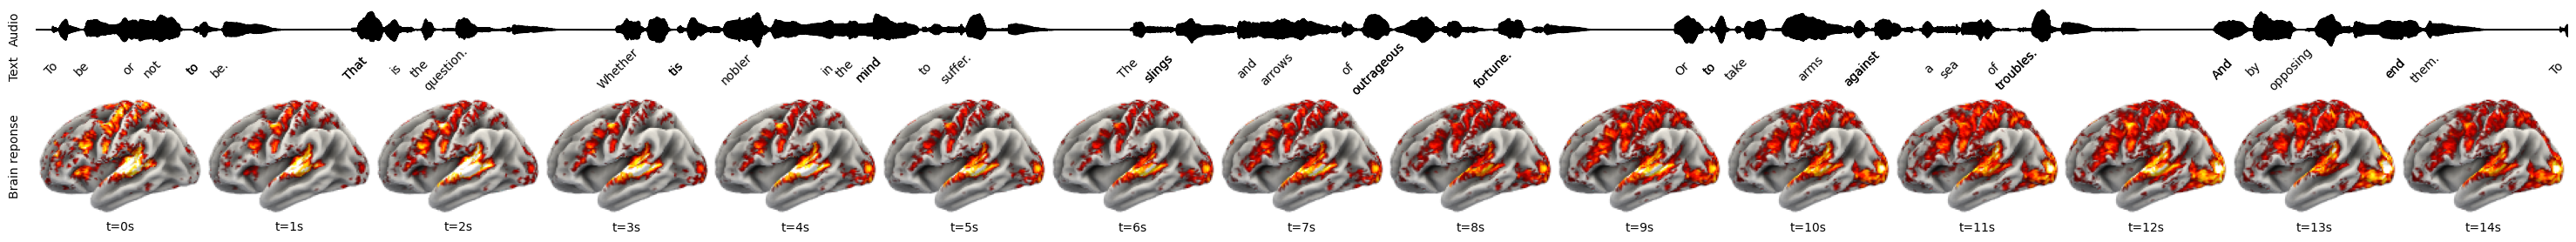

In [ ]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.5, alpha_cmap=(0, .2), show_stimuli=True)